In [ ]:
import pandas as pd
import json
import urllib.request
import re
from rdflib import Graph
from rapidfuzz import fuzz, process
from datetime import datetime
import geopandas as gpd
from shapely import wkt

import numpy as np
from tqdm import tqdm

In [ ]:
gavoc_uri = 'https://www.zotero.org/groups/4678659/items/HRI8XQQI'

In [ ]:
gavoc = pd.read_csv("../data/gavoc-atlas-index.csv")

In [ ]:
gavoc = gavoc.fillna('-')

In [ ]:
gavoc.columns

Index(['id', 'Index page', 'Oorspr. naam op de kaart/Original name on the map',
       'Tegenwoordige naam/Present name', 'Soortnaam/Category',
       'Coördinaten/Coordinates', 'Kaartvak/Map grid square', 'Kaart/Map',
       'Pagina/Page'],
      dtype='str')

In [ ]:
gavoc

,id,Index page,Oorspr. naam op de kaart/Original name on the map,Tegenwoordige naam/Present name,Soortnaam/Category,Coördinaten/Coordinates,Kaartvak/Map grid square,Kaart/Map,Pagina/Page
0,1,399,Aajer Gila,-,rivier/river,-,B2R,I-39a,p. 226
1,2,399,"Aandomaon, Ilha de",Andamanen/Andaman Islands,eilanden/islands,12-30N/92-50E,A2-B2,I-31,p. 212
2,3,399,Aapjesberg,Apenberg/Bukit Monyet,berg/mountain,00-58S/100-20E,B3,I-34,p. 214
3,4,399,Aarnhems Land,Arnhem Land,landstreek/region,13-30S/134E,A3,II-1a,p. 234
4,5,399,Aarnhems Landt,Arnhem Land,landstreek/region,13-30S/134E,B3,I-1,p. 40
...,...,...,...,...,...,...,...,...,...
11079,11080,417,Z.W. Hoek,Noma Misaki,kaap/cape,31-24N/130-06E,A3,II-36,p. 360
11080,11081,417,Zydapurnae,Sidopoerna/Sidopurna,plaats/settlement,07-25S/112-42E,B3,II-2i,p. 248
11081,11082,417,"Zyl Eylandt, t",Menon,eiland/island,01-21S/130-43E,B2,II-46b,p. 390
11082,11083,417,"Zyle, Eyl.",Kokoja/Kokoya,eiland/island,02-01N/128-14E,A2,II-28,p. 338


In [ ]:
def dms_to_wkt(coord_str):
    """
    Convert a coordinate string like '12-30N/92-50E' or '13-30S/134E'
    into a WKT POINT. Handles missing minutes/seconds gracefully.
    Format: <deg>[-<min>[-<sec>]]<N|S>/<deg>[-<min>[-<sec>]]<E|W>
    Returns 'POINT(lon lat)' or None if parsing fails.
    """
    if not isinstance(coord_str, str) or not coord_str.strip():
        return 'POINT EMPTY'

    # each half: 1-3 digits for degrees, optional -mm, optional -ss, then direction letter
    part = r"(\d{1,3})(?:-(\d{1,2}))?(?:-(\d{1,2}))?\s*([NSEW])"
    pattern = rf"{part}\s*/\s*{part}"

    match = re.match(pattern, coord_str.strip(), re.IGNORECASE)
    if not match:
        return 'POINT EMPTY'

    d1, m1, s1, dir1, d2, m2, s2, dir2 = match.groups()

    def to_decimal(deg, minutes, seconds, direction):
        deg = int(deg)
        minutes = int(minutes) if minutes else 0
        seconds = int(seconds) if seconds else 0
        value = deg + minutes / 60 + seconds / 3600
        if direction.upper() in ('S', 'W'):
            value = -value
        return value

    dirs = {dir1.upper(), dir2.upper()}
    val1 = to_decimal(d1, m1, s1, dir1)
    val2 = to_decimal(d2, m2, s2, dir2)

    # figure out which value is lat (N/S) and which is lon (E/W)
    if dir1.upper() in ('N', 'S'):
        lat, lon = val1, val2
    else:
        lat, lon = val2, val1

    return f"POINT({lon:.6f} {lat:.6f})"
    

In [ ]:
gavoc['point_coord'] = gavoc['Coördinaten/Coordinates'].apply(dms_to_wkt)

In [ ]:
gavoc

,id,Index page,Oorspr. naam op de kaart/Original name on the map,Tegenwoordige naam/Present name,Soortnaam/Category,Coördinaten/Coordinates,Kaartvak/Map grid square,Kaart/Map,Pagina/Page,point_coord
0,1,399,Aajer Gila,-,rivier/river,-,B2R,I-39a,p. 226,POINT EMPTY
1,2,399,"Aandomaon, Ilha de",Andamanen/Andaman Islands,eilanden/islands,12-30N/92-50E,A2-B2,I-31,p. 212,POINT(92.833333 12.500000)
2,3,399,Aapjesberg,Apenberg/Bukit Monyet,berg/mountain,00-58S/100-20E,B3,I-34,p. 214,POINT(100.333333 -0.966667)
3,4,399,Aarnhems Land,Arnhem Land,landstreek/region,13-30S/134E,A3,II-1a,p. 234,POINT(134.000000 -13.500000)
4,5,399,Aarnhems Landt,Arnhem Land,landstreek/region,13-30S/134E,B3,I-1,p. 40,POINT(134.000000 -13.500000)
...,...,...,...,...,...,...,...,...,...,...
11079,11080,417,Z.W. Hoek,Noma Misaki,kaap/cape,31-24N/130-06E,A3,II-36,p. 360,POINT(130.100000 31.400000)
11080,11081,417,Zydapurnae,Sidopoerna/Sidopurna,plaats/settlement,07-25S/112-42E,B3,II-2i,p. 248,POINT(112.700000 -7.416667)
11081,11082,417,"Zyl Eylandt, t",Menon,eiland/island,01-21S/130-43E,B2,II-46b,p. 390,POINT(130.716667 -1.350000)
11082,11083,417,"Zyle, Eyl.",Kokoja/Kokoya,eiland/island,02-01N/128-14E,A2,II-28,p. 338,POINT(128.233333 2.016667)


In [ ]:
def split_category(category):
    category = category.replace(' and ', ', ').replace(' en ', ', ')
    
    if len(category.split('/'))==2:
        return [cat.strip() for cat in category.split('/')]
    else:
        return [category, category]

In [ ]:
def pref_label(present_name):
    return present_name.split('/')[-1].strip('? []<>')


In [ ]:
gavoc['source'] = gavoc_uri

In [ ]:
gavoc

,id,Index page,Oorspr. naam op de kaart/Original name on the map,Tegenwoordige naam/Present name,Soortnaam/Category,Coördinaten/Coordinates,Kaartvak/Map grid square,Kaart/Map,Pagina/Page,point_coord,source
0,1,399,Aajer Gila,-,rivier/river,-,B2R,I-39a,p. 226,POINT EMPTY,https://www.zotero.org/groups/4678659/items/HR...
1,2,399,"Aandomaon, Ilha de",Andamanen/Andaman Islands,eilanden/islands,12-30N/92-50E,A2-B2,I-31,p. 212,POINT(92.833333 12.500000),https://www.zotero.org/groups/4678659/items/HR...
2,3,399,Aapjesberg,Apenberg/Bukit Monyet,berg/mountain,00-58S/100-20E,B3,I-34,p. 214,POINT(100.333333 -0.966667),https://www.zotero.org/groups/4678659/items/HR...
3,4,399,Aarnhems Land,Arnhem Land,landstreek/region,13-30S/134E,A3,II-1a,p. 234,POINT(134.000000 -13.500000),https://www.zotero.org/groups/4678659/items/HR...
4,5,399,Aarnhems Landt,Arnhem Land,landstreek/region,13-30S/134E,B3,I-1,p. 40,POINT(134.000000 -13.500000),https://www.zotero.org/groups/4678659/items/HR...
...,...,...,...,...,...,...,...,...,...,...,...
11079,11080,417,Z.W. Hoek,Noma Misaki,kaap/cape,31-24N/130-06E,A3,II-36,p. 360,POINT(130.100000 31.400000),https://www.zotero.org/groups/4678659/items/HR...
11080,11081,417,Zydapurnae,Sidopoerna/Sidopurna,plaats/settlement,07-25S/112-42E,B3,II-2i,p. 248,POINT(112.700000 -7.416667),https://www.zotero.org/groups/4678659/items/HR...
11081,11082,417,"Zyl Eylandt, t",Menon,eiland/island,01-21S/130-43E,B2,II-46b,p. 390,POINT(130.716667 -1.350000),https://www.zotero.org/groups/4678659/items/HR...
11082,11083,417,"Zyle, Eyl.",Kokoja/Kokoya,eiland/island,02-01N/128-14E,A2,II-28,p. 338,POINT(128.233333 2.016667),https://www.zotero.org/groups/4678659/items/HR...


In [ ]:
def make_map_page(row):
    return f"map {row['Kaart/Map']} ({row['Kaartvak/Map grid square']}) on {row['Pagina/Page']}"

## TYPES

In [ ]:
def create_ttl_df_label(ttl_file):
    g = Graph()
    g.parse(ttl_file)
    
    q = """
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

    SELECT ?uri ?property ?label
    WHERE {
      ?uri skos:inScheme <https://digitaalerfgoed.poolparty.biz/globalise/05ae4d21-077b-4a2b-956b-bf5661ee1d16> ;
           ?property ?label .
      FILTER (?property IN (skos:prefLabel, skos:altLabel, skos:hiddenLabel))
    }
    """
    
    qres = g.query(q)
    
    label_type_map = {
        "http://www.w3.org/2004/02/skos/core#prefLabel": "prefLabel",
        "http://www.w3.org/2004/02/skos/core#altLabel": "altLabel",
        "http://www.w3.org/2004/02/skos/core#hiddenLabel": "hiddenLabel",
    }
    
    rows = []
    for uri, property, literal in qres:
        rows.append({
            "uri": str(uri),
            "label": str(literal).lower(),
            "label_type": label_type_map.get(str(property), str(property)),
            "language": literal.language
        })
    
    return pd.DataFrame(rows, columns=["uri", "label", "label_type", "language"])

In [ ]:
place_type_labels = create_ttl_df_label('../data/pp_scheme_plaatstypen.ttl')

In [ ]:
gavoc[['place_type_nl', 'place_type']] = gavoc['Soortnaam/Category'].apply(split_category).apply(pd.Series)

In [ ]:
gavoc_types = gavoc[[
    'id',
    'Soortnaam/Category',
    'place_type_nl',
    'place_type',
    'source',
    'Index page',
]].copy()

In [ ]:
gavoc_types = gavoc_types.rename(columns={
    'Index page': 'source_page',
    'Soortnaam/Category': 'place_type_original',
})

In [ ]:
# split out multiple places in one field
gavoc_types['place_type'] = gavoc_types['place_type'].apply(lambda x: [pt.strip() for pt in x.split(',')])
gavoc_types = gavoc_types.explode('place_type')

# get rid of the ones that still have two languages
gavoc_types['place_type'] = gavoc_types['place_type'].apply(lambda x: x.split('/')[-1])
gavoc_types['place_type'] = gavoc_types['place_type'].apply(lambda x: x.split('.')[-1])
gavoc_types = gavoc_types[gavoc_types['place_type']!='-']
gavoc_types['place_type'] = gavoc_types['place_type'].apply(lambda x: x.replace('islands', 'archipelago'))


In [ ]:
gavoc_types['place_type'].sort_values().unique()

<ArrowStringArray>
[             '?',    'archipelago',            'bay',         'beacon',
         'bridge',       'building',          'canal',           'cape',
       'causeway',          'cliff',          'coast',       'eilanden',
           'farm',           'ford',         'forest', 'fortified post',
       'fortress',           'gulf',           'hill',          'inlet',
         'island',        'isthmus',         'lagoon',           'lake',
       'mountain',      'mountains',      'peninsula',       'province',
           'reef',          'reefs',         'region',      'reservoir',
          'river',         'rivier',           'road',      'roadstead',
       'salt pan',      'salt pans',        'sandbar',            'sea',
      'setlement',     'settlement',       'shallows',         'shoals',
         'strait',         'street',          'swamp',  'town district',
         'valley', 'watering place',           'wijk']
Length: 51, dtype: str

In [ ]:
unique_types = pd.DataFrame(gavoc_types['place_type'].drop_duplicates().copy())

In [ ]:
def find_type_match(candidate_type):
    matches = process.extract(
    candidate_type,
    place_type_labels[place_type_labels['language']=='en']['label'],
    scorer=fuzz.ratio,
    limit=1,
    score_cutoff=82
    )
    if len(matches) == 0:
        return ['-','-', '-']
    else: 
        match_index = matches[0][2]
        pp_uri = place_type_labels.iloc[match_index]['uri']
        return [matches[0][0], pp_uri, matches[0][1]]

In [ ]:
unique_types[['pp_type_label','pp_uri','match_score']] = unique_types['place_type'].apply(find_type_match).apply(pd.Series)

In [ ]:
gavoc_types = pd.merge(gavoc_types, unique_types[['place_type', 'pp_type_label', 'pp_uri']], how='left', on='place_type')

## STANDARD PLACE

In [ ]:
gavoc['map_page'] = gavoc[['Pagina/Page', 'Kaart/Map', 'Kaartvak/Map grid square']].apply(make_map_page, axis=1)

In [ ]:
gavoc['pref_label'] = gavoc['Tegenwoordige naam/Present name'].apply(pref_label)

In [ ]:
gavoc = pd.merge(gavoc, gavoc_types[['id', 'pp_type_label']], how='left', on='id')
gavoc['pp_type_label'] = gavoc['pp_type_label'].fillna('-')

In [ ]:
identification_columns = ['pref_label', 'Coördinaten/Coordinates', 'pp_type_label']

In [ ]:
gavoc['join_values'] = gavoc[identification_columns].apply(lambda row: '|'.join(row.values.astype(str)).lower(), axis=1)

gavoc_places = gavoc[[
    'pref_label',
    'Coördinaten/Coordinates',
    'pp_type_label',
    'join_values',
]].copy()

gavoc_places = gavoc_places[(gavoc_places['pref_label']!='-') | (gavoc_places['Coördinaten/Coordinates']!='-')].copy()

gavoc_places = gavoc_places.drop_duplicates().reset_index().copy()
gavoc_places['external_id'] = gavoc_places['index'].apply(lambda x: f"GLOB_GAVOC_{str(x).zfill(5)}")
gavoc = pd.merge(gavoc, gavoc_places[['join_values', 'external_id']], on='join_values', how='left')
gavoc_places.sort_values('pref_label')

,index,pref_label,Coördinaten/Coordinates,pp_type_label,join_values,external_id
23,45,-,00-05-30S/127-26E,islands,-|00-05-30s/127-26e|islands,GLOB_GAVOC_00045
37,82,-,27-10N/78-01E,settlements,-|27-10n/78-01e|settlements,GLOB_GAVOC_00082
61,115,-,03-17S/127-55E,-,-|03-17s/127-55e|-,GLOB_GAVOC_00115
94,178,-,06-55N/79-50E,settlements,-|06-55n/79-50e|settlements,GLOB_GAVOC_00178
97,185,-,08-46N/99-56E,-,-|08-46n/99-56e|-,GLOB_GAVOC_00185
...,...,...,...,...,...,...
4913,10631,islands SE of Misool,02-10S/130-35E,archipelago,islands se of misool|02-10s/130-35e|archipelago,GLOB_GAVOC_10631
1539,3179,near Mutur,08-25N/81-13E,-,near mutur|08-25n/81-13e|-,GLOB_GAVOC_03179
998,2090,near present al-Hudaydah,14-48N/42-55E,settlements,near present al-hudaydah|14-48n/42-55e|settlem...,GLOB_GAVOC_02090
3829,8284,of Nanjishan Liedao,27-28N/120-52E,straits,of nanjishan liedao|27-28n/120-52e|straits,GLOB_GAVOC_08284


In [ ]:
# add IDs for places that only have attestation
gavoc['external_id'] = gavoc['external_id'].fillna(gavoc['id'].apply(lambda x: f'GLOB_GAVOC_{x + 80000}'))

## LABELS

In [ ]:
gavoc['standard_empty'] = gavoc['Tegenwoordige naam/Present name'].apply(lambda x: False if x != '-' else True)

In [ ]:
gavoc.columns

Index(['id', 'Index page', 'Oorspr. naam op de kaart/Original name on the map',
       'Tegenwoordige naam/Present name', 'Soortnaam/Category',
       'Coördinaten/Coordinates', 'Kaartvak/Map grid square', 'Kaart/Map',
       'Pagina/Page', 'point_coord', 'source', 'place_type_nl', 'place_type',
       'map_page', 'pref_label', 'pp_type_label', 'join_values', 'external_id',
       'standard_empty'],
      dtype='str')

In [ ]:
gavoc_attestation_labels = gavoc[['external_id', 'id', 'Oorspr. naam op de kaart/Original name on the map', 'source', 'map_page', 'standard_empty']]

In [ ]:
gavoc_attestation_labels = gavoc_attestation_labels.rename(columns={
    'id': 'attestation_id',
    'map_page': 'source_page',
    'Oorspr. naam op de kaart/Original name on the map': 'label',
    'standard_empty': 'label_type'
})

In [ ]:
gavoc_attestation_labels['label_type'] = gavoc_attestation_labels['label_type'].apply(lambda x: 'PREF' if x else 'ALT')

In [ ]:
gavoc_attestation_labels['set'] = 'attestations'

Now I will process the "Present labels"

In [ ]:
gavoc_present_labels = gavoc[~gavoc['standard_empty']][['external_id', 'id', 'Tegenwoordige naam/Present name', 'source', 'Index page', 'pref_label']].copy()

In [ ]:
gavoc_present_labels = gavoc_present_labels.rename(columns={
    'id': 'attestation_id',
    'Index page': 'source_page',
    'Tegenwoordige naam/Present name': 'label',
})

In [ ]:
gavoc_present_labels['label'] = gavoc_present_labels['label'].apply(lambda x: [label.strip(' ?<>[]') for label in x.split('/')])

In [ ]:
gavoc_present_labels = gavoc_present_labels.explode('label')

In [ ]:
group_by_cols = ['external_id', 'label']

In [ ]:
gavoc_present_labels['group_by'] = gavoc_present_labels['external_id'] + gavoc_present_labels['label']

In [ ]:
gavoc_present_labels['attestation_id'] = gavoc_present_labels['attestation_id'].apply(lambda x: f'{x}')
gavoc_present_labels['source_page'] = gavoc_present_labels['source_page'].apply(lambda x: f'{x}')

In [ ]:
gavoc_present_labels = gavoc_present_labels.groupby('group_by').agg(lambda col: list(set(col)))

In [ ]:
gavoc_present_labels = gavoc_present_labels.reset_index().drop(columns=['group_by']).map(lambda x: ', '.join(x))

In [ ]:
gavoc_present_labels['label_type'] = gavoc_present_labels['label'] == gavoc_present_labels['pref_label']
gavoc_present_labels['label_type'] = gavoc_present_labels['label_type'].apply(lambda x: 'PREF' if x else 'ALT')

In [ ]:
gavoc_present_labels['set'] = 'present'

In [ ]:
cols = list(gavoc_attestation_labels.columns)

In [ ]:
gavoc_labels = pd.concat([gavoc_attestation_labels, gavoc_present_labels[cols]])

In [ ]:
gavoc_labels

,external_id,attestation_id,label,source,source_page,label_type,set
0,GLOB_GAVOC_80001,1,Aajer Gila,https://www.zotero.org/groups/4678659/items/HR...,map I-39a (B2R) on p. 226,PREF,attestations
1,GLOB_GAVOC_00001,2,"Aandomaon, Ilha de",https://www.zotero.org/groups/4678659/items/HR...,map I-31 (A2-B2) on p. 212,ALT,attestations
2,GLOB_GAVOC_00002,3,Aapjesberg,https://www.zotero.org/groups/4678659/items/HR...,map I-34 (B3) on p. 214,ALT,attestations
3,GLOB_GAVOC_00003,4,Aarnhems Land,https://www.zotero.org/groups/4678659/items/HR...,map II-1a (A3) on p. 234,ALT,attestations
4,GLOB_GAVOC_00003,5,Aarnhems Landt,https://www.zotero.org/groups/4678659/items/HR...,map I-1 (B3) on p. 40,ALT,attestations
...,...,...,...,...,...,...,...
7127,GLOB_GAVOC_11168,11080,Noma Misaki,https://www.zotero.org/groups/4678659/items/HR...,417,PREF,present
7128,GLOB_GAVOC_11169,11081,Sidopoerna,https://www.zotero.org/groups/4678659/items/HR...,417,ALT,present
7129,GLOB_GAVOC_11169,11081,Sidopurna,https://www.zotero.org/groups/4678659/items/HR...,417,PREF,present
7130,GLOB_GAVOC_11171,11083,Kokoja,https://www.zotero.org/groups/4678659/items/HR...,417,ALT,present


## Other stuff

In [ ]:
gavoc

,id,Index page,Oorspr. naam op de kaart/Original name on the map,Tegenwoordige naam/Present name,Soortnaam/Category,Coördinaten/Coordinates,Kaartvak/Map grid square,Kaart/Map,Pagina/Page,point_coord,source,place_type_nl,place_type,map_page,pref_label,pp_type_label,join_values,external_id,standard_empty
0,1,399,Aajer Gila,-,rivier/river,-,B2R,I-39a,p. 226,POINT EMPTY,https://www.zotero.org/groups/4678659/items/HR...,rivier,river,map I-39a (B2R) on p. 226,-,rivers,-|-|rivers,GLOB_GAVOC_80001,True
1,2,399,"Aandomaon, Ilha de",Andamanen/Andaman Islands,eilanden/islands,12-30N/92-50E,A2-B2,I-31,p. 212,POINT(92.833333 12.500000),https://www.zotero.org/groups/4678659/items/HR...,eilanden,islands,map I-31 (A2-B2) on p. 212,Andaman Islands,archipelago,andaman islands|12-30n/92-50e|archipelago,GLOB_GAVOC_00001,False
2,3,399,Aapjesberg,Apenberg/Bukit Monyet,berg/mountain,00-58S/100-20E,B3,I-34,p. 214,POINT(100.333333 -0.966667),https://www.zotero.org/groups/4678659/items/HR...,berg,mountain,map I-34 (B3) on p. 214,Bukit Monyet,mountains,bukit monyet|00-58s/100-20e|mountains,GLOB_GAVOC_00002,False
3,4,399,Aarnhems Land,Arnhem Land,landstreek/region,13-30S/134E,A3,II-1a,p. 234,POINT(134.000000 -13.500000),https://www.zotero.org/groups/4678659/items/HR...,landstreek,region,map II-1a (A3) on p. 234,Arnhem Land,regions,arnhem land|13-30s/134e|regions,GLOB_GAVOC_00003,False
4,5,399,Aarnhems Landt,Arnhem Land,landstreek/region,13-30S/134E,B3,I-1,p. 40,POINT(134.000000 -13.500000),https://www.zotero.org/groups/4678659/items/HR...,landstreek,region,map I-1 (B3) on p. 40,Arnhem Land,regions,arnhem land|13-30s/134e|regions,GLOB_GAVOC_00003,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11179,11080,417,Z.W. Hoek,Noma Misaki,kaap/cape,31-24N/130-06E,A3,II-36,p. 360,POINT(130.100000 31.400000),https://www.zotero.org/groups/4678659/items/HR...,kaap,cape,map II-36 (A3) on p. 360,Noma Misaki,capes,noma misaki|31-24n/130-06e|capes,GLOB_GAVOC_11168,False
11180,11081,417,Zydapurnae,Sidopoerna/Sidopurna,plaats/settlement,07-25S/112-42E,B3,II-2i,p. 248,POINT(112.700000 -7.416667),https://www.zotero.org/groups/4678659/items/HR...,plaats,settlement,map II-2i (B3) on p. 248,Sidopurna,settlements,sidopurna|07-25s/112-42e|settlements,GLOB_GAVOC_11169,False
11181,11082,417,"Zyl Eylandt, t",Menon,eiland/island,01-21S/130-43E,B2,II-46b,p. 390,POINT(130.716667 -1.350000),https://www.zotero.org/groups/4678659/items/HR...,eiland,island,map II-46b (B2) on p. 390,Menon,islands,menon|01-21s/130-43e|islands,GLOB_GAVOC_11104,False
11182,11083,417,"Zyle, Eyl.",Kokoja/Kokoya,eiland/island,02-01N/128-14E,A2,II-28,p. 338,POINT(128.233333 2.016667),https://www.zotero.org/groups/4678659/items/HR...,eiland,island,map II-28 (A2) on p. 338,Kokoya,islands,kokoya|02-01n/128-14e|islands,GLOB_GAVOC_11171,False


In [ ]:

# outgoing form of gavoc_types
gavoc_types = pd.merge(gavoc[['external_id', 'id']], gavoc_types, how='right', on='id')

In [ ]:

gavoc_types = gavoc_types.groupby(['external_id', 'pp_uri']).agg(lambda col: list(set(col))).reset_index()


In [ ]:
gavoc_types

,external_id,pp_uri,id,place_type_original,place_type_nl,place_type,source,source_page,pp_type_label
0,GLOB_GAVOC_00001,https://digitaalerfgoed.poolparty.biz/globalis...,"[2, 307, 308]",[eilanden/islands],[eilanden],[archipelago],[https://www.zotero.org/groups/4678659/items/H...,[399],[archipelago]
1,GLOB_GAVOC_00002,https://digitaalerfgoed.poolparty.biz/globalis...,[3],[berg/mountain],[berg],[mountain],[https://www.zotero.org/groups/4678659/items/H...,[399],[mountains]
2,GLOB_GAVOC_00003,https://digitaalerfgoed.poolparty.biz/globalis...,"[4, 5]",[landstreek/region],[landstreek],[region],[https://www.zotero.org/groups/4678659/items/H...,[399],[regions]
3,GLOB_GAVOC_00005,https://digitaalerfgoed.poolparty.biz/globalis...,"[6, 7]",[kaap/cape],[kaap],[cape],[https://www.zotero.org/groups/4678659/items/H...,[399],[capes]
4,GLOB_GAVOC_00007,https://digitaalerfgoed.poolparty.biz/globalis...,[8],[rivier/river],[rivier],[river],[https://www.zotero.org/groups/4678659/items/H...,[399],[rivers]
...,...,...,...,...,...,...,...,...,...
8241,GLOB_GAVOC_91056,https://digitaalerfgoed.poolparty.biz/globalis...,[11056],[plaats/settlement],[plaats],[settlement],[https://www.zotero.org/groups/4678659/items/H...,[417],[settlements]
8242,GLOB_GAVOC_91063,https://digitaalerfgoed.poolparty.biz/globalis...,[11063],[plaats/settlement],[plaats],[settlement],[https://www.zotero.org/groups/4678659/items/H...,[417],[settlements]
8243,GLOB_GAVOC_91072,https://digitaalerfgoed.poolparty.biz/globalis...,[11072],[gebergte/mountains],[gebergte],[mountains],[https://www.zotero.org/groups/4678659/items/H...,[417],[mountains]
8244,GLOB_GAVOC_91078,https://digitaalerfgoed.poolparty.biz/globalis...,[11078],[rivier/river],[rivier],[river],[https://www.zotero.org/groups/4678659/items/H...,[417],[rivers]


In [ ]:
gavoc_types[[
    'id', 'place_type_original', 'place_type_nl',
    'place_type', 'source', 'source_page', 'pp_type_label'
    ]] = gavoc_types[[
    'id', 'place_type_original', 'place_type_nl',
    'place_type', 'source', 'source_page', 'pp_type_label'
    ]].map(lambda x: ', '.join([str(i) for i in x]))

In [ ]:

gavoc_overview = gpd.GeoDataFrame(gavoc)
coord_strings = gavoc_overview["point_coord"]
gavoc_overview["point_coord"] = gpd.GeoSeries.from_wkt(coord_strings)
gavoc_overview = gavoc_overview.set_geometry("point_coord")
gavoc_overview['longitude'] = gavoc_overview.geometry.x
gavoc_overview['latitude'] = gavoc_overview.geometry.y

In [ ]:
gavoc_overview = gavoc_overview.rename(columns={
    'Index page': 'coord_source_page',
    'id': 'attestation_id',
    'source': 'coord_source',
    'Coördinaten/Coordinates': 'coord_remarks',
})

In [ ]:
gavoc_overview = gavoc_overview[['external_id', 'longitude', 'latitude', 'point_coord', 'coord_source', 'coord_source_page', 'coord_remarks', 'attestation_id']].copy()

In [ ]:
prefs = gavoc_labels[gavoc_labels['label_type']=='PREF']

In [ ]:
prefs = prefs[['external_id', 'label']].rename(columns={'label': 'pref_label'})

In [ ]:
gavoc_overview = pd.merge(gavoc_overview, gavoc_types[['place_type','external_id','pp_uri','pp_type_label']], how='outer', on='external_id')

In [ ]:
gavoc_overview = pd.merge(gavoc_overview, prefs, how='left', on='external_id')

In [ ]:
gavoc_overview = pd.merge(gavoc_overview, gavoc_labels[['external_id', 'label']], how='outer', on='external_id')

In [ ]:
gavoc_overview = gavoc_overview.fillna('-')

In [ ]:
gavoc_overview = gavoc_overview.groupby('external_id').agg(lambda col: list(set(col))).map(lambda x: '|'.join([str(i) for i in x]))

In [ ]:
gavoc_overview = gavoc_overview.reset_index()

In [ ]:
gavoc_overview = gavoc_overview[[
    'external_id',
    'pref_label',
    'label',
    'longitude', 
    'latitude', 
    'point_coord', 
    'coord_source',
    'coord_source_page', 
    'coord_remarks', 
    'place_type', 
    'pp_uri',
    'pp_type_label',
    'attestation_id'
]].copy()

In [ ]:
gavoc_overview.sort_values('pref_label')

,external_id,pref_label,label,longitude,latitude,point_coord,coord_source,coord_source_page,coord_remarks,place_type,pp_uri,pp_type_label,attestation_id
2579,GLOB_GAVOC_05443,-,Lysters riff|-|Westbank,122.866667,-4.016667,POINT (122.866667 -4.016667),https://www.zotero.org/groups/4678659/items/HR...,407,04-01S/122-52E,shoals,https://digitaalerfgoed.poolparty.biz/globalis...,shoals,5403
2778,GLOB_GAVOC_05922,1st Cross Street,"1st Cross Street|Marktstraat, De",79.833333,6.933333,POINT (79.833333 6.933333),https://www.zotero.org/groups/4678659/items/HR...,408,06-56N/79-50E,street,https://digitaalerfgoed.poolparty.biz/globalis...,streets,5881
1681,GLOB_GAVOC_03456,2 Gebroeders,2 Gebroeders,113.416667,22.016667,POINT (113.416667 22.016667),https://www.zotero.org/groups/4678659/items/HR...,404,22-01N/113-25E,archipelago,https://digitaalerfgoed.poolparty.biz/globalis...,archipelago,3432
6136,GLOB_GAVOC_83433,"2 Gebroeders, De","2 Gebroeders, De",-,-,POINT EMPTY,https://www.zotero.org/groups/4678659/items/HR...,404,-,archipelago,https://digitaalerfgoed.poolparty.biz/globalis...,archipelago,3433
6150,GLOB_GAVOC_83484,2 Gesus,2 Gesus,-,-,POINT EMPTY,https://www.zotero.org/groups/4678659/items/HR...,404,-,archipelago,https://digitaalerfgoed.poolparty.biz/globalis...,archipelago,3484
...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,GLOB_GAVOC_02090,near present al-Hudaydah,bij huidige|bij near huidige|Cazobibi|Gazebibe...,42.916667,14.8,POINT (42.916667 14.8),https://www.zotero.org/groups/4678659/items/HR...,402|404,14-48N/42-55E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,3424|2077
3829,GLOB_GAVOC_08284,of Nanjishan Liedao,Ramekens en Everveens doortocht|of Nanjishan L...,120.866667,27.466667,POINT (120.866667 27.466667),https://www.zotero.org/groups/4678659/items/HR...,412,27-28N/120-52E,strait,https://digitaalerfgoed.poolparty.biz/globalis...,straits,8210
3717,GLOB_GAVOC_08025,southern part of Sakhalin,southern part of Sakhalin|Poortlandt|zuidelijk...,142.25,46.333333,POINT (142.25 46.333333),https://www.zotero.org/groups/4678659/items/HR...,412,46-20N/142-15E,region,https://digitaalerfgoed.poolparty.biz/globalis...,regions,7954
6031,GLOB_GAVOC_82970,van Driehoek,van Driehoek,-,-,POINT EMPTY,https://www.zotero.org/groups/4678659/items/HR...,403,-,archipelago,https://digitaalerfgoed.poolparty.biz/globalis...,archipelago,2970


## Quick View

In [ ]:
gavoc_gdf = gpd.GeoDataFrame(gavoc_overview)
coord_strings = gavoc_gdf["point_coord"] #.replace(r'^\s*$', None, regex=True)
gavoc_gdf["point_coord"] = gpd.GeoSeries.from_wkt(coord_strings)
gavoc_gdf = gavoc_gdf.set_geometry("point_coord")

<Axes: >

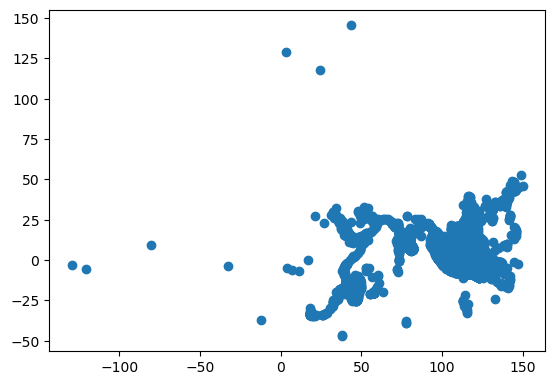

In [ ]:
gavoc_gdf.plot()

In [ ]:
gavoc_gdf['place_type']

0       archipelago
1          mountain
2            region
3              cape
4             river
           ...     
8633              -
8634      mountains
8635              -
8636          river
8637         island
Name: place_type, Length: 8638, dtype: str

In [ ]:
import plotly.express as px
fig = px.scatter_geo(gavoc_gdf, 
                    color="place_type",
                    lat=gavoc_gdf.geometry.y,
                    lon=gavoc_gdf.geometry.x,)
fig.show()

## Create Internal Matches

In [ ]:
def find_match(label, candidates, precision=82, cols=['glob_id','pref_label','label'], candidate_col='label'):
    candidates = candidates[cols]
    
    matches = process.extract(
    label,
    candidates[candidate_col],
    scorer=fuzz.ratio,
    limit=5,
    score_cutoff=precision
    )
    if len(matches) == 0:
        return None

    # Extract indices and scores
    top_indices = [match[2] for match in matches]
    scores = [match[1] for match in matches]
    
    # Select the rows and add similarity score
    top_rows = candidates.iloc[top_indices].copy()
    top_rows['similarity_score'] = scores
    
    # Sort by similarity score descending
    top_rows = top_rows.sort_values(by='similarity_score', ascending=False)
    
    return top_rows

In [ ]:
def pare_down_matches(matched_rows, groupby_col='glob_id'):
    if len(matched_rows) < 2:
        return matched_rows
    
    return matched_rows.groupby(groupby_col).max().reset_index()

In [ ]:
def add_match_metadata(matched_rows, method, external_id):
    matched_rows['method'] = method
    matched_rows['matched_id'] = external_id
    return matched_rows

In [ ]:
def find_internal_match(df, distance=1, no_coords_skip=True, precision=85):
    matched_results = []
    passed_rows = []
    for i, row in tqdm(df.iterrows(), total=df.shape[0]):
        ref_point = row['point_coord']  
        if not ref_point.is_empty:
            matchable_options = df[
                (df.geometry.distance(ref_point) <= distance) & 
                (df.external_id != row.external_id) &
                (df.pp_type_label == row.pp_type_label)
                ].reset_index().copy()
            candidate_matches = [
                find_match(label, 
                           matchable_options, 
                           precision=precision,
                           cols=['external_id','pref_label','label'], 
                           candidate_col='pref_label'
                           ) for label in row['label'].split('|')]
            candidate_matches = [i for i in candidate_matches if i is not None]
            if len(candidate_matches)>0:
                candidate_matches = pd.concat(candidate_matches)
                candidate_matches = pare_down_matches(candidate_matches, 'external_id')
                candidate_matches = add_match_metadata(
                    candidate_matches,
                    f'{distance}',
                    row['external_id'],
                )
                matched_results.append(candidate_matches)
            else:
                passed_rows.append(row)
        else:
            passed_rows.append(row)
    return pd.concat(matched_results), pd.DataFrame(passed_rows)

In [ ]:
def combine_internal_matches(internal_matches, df):
    internal_matches = internal_matches[['external_id', 'matched_id']].groupby('external_id').agg(lambda col: list(set(col))).reset_index()

    df = pd.merge(df, internal_matches, how='left', on='external_id')
    df['matched_id'] = df['matched_id'].fillna('-')

    matched_list = list(df[['external_id', 'matched_id']].apply(
        lambda row: sorted([row.external_id] + row.matched_id) if row.matched_id != '-' else [row.external_id], axis=1)
        )
    
    match_dict = {}
    for ls in matched_list:
        # first id in ls becomes default
        for id in ls:
            match_dict[id] = ls[0]
    # df['group_by_id'] = df['group_by_id'].apply(lambda x: '|'.join(x))
    # df = df.drop('matched_id', axis=1)
    # df = df.groupby('group_by_id').agg(lambda col: list(set(col))).reset_index()

    return match_dict

In [ ]:
gavoc_gdf = gavoc_gdf.set_crs('3857')

In [ ]:
internal_matches, unmatched = find_internal_match(gavoc_gdf)

100%|██████████| 8638/8638 [00:08<00:00, 1026.79it/s]


In [ ]:
# x = combine_internal_matches(internal_matches, gavoc_gdf)
# x[x.external_id.apply(lambda x: len(x))>1]

In [ ]:
int_match_dict = combine_internal_matches(internal_matches, gavoc_gdf)

In [ ]:
def collapse_updated_df(df, group_by_cols, join_symbol):
    df = df.groupby(group_by_cols).agg(lambda col: list(set(col))).map(lambda x: f'{join_symbol}'.join([str(i) for i in x])).reset_index()
    return df

In [ ]:
def update_ids(df, match_dict, collapse=True, group_by_cols=['external_id'], join_symbol=', '):
    df = df.copy()
    df['former_external_id'] = list(df['external_id'])
    df['external_id'] = df['external_id'].apply(lambda x: match_dict[x])
    df = df.map(lambda x: f'{x}')

    if collapse: 
        df = collapse_updated_df(df, group_by_cols, join_symbol)

    return df.sort_values('external_id')


In [ ]:
gavoc_types = update_ids(gavoc_types, int_match_dict, group_by_cols=['external_id', 'pp_type_label'])

In [ ]:
gavoc_labels = update_ids(gavoc_labels, int_match_dict, group_by_cols=['external_id', 'label', 'label_type'])

In [ ]:
len(gavoc_overview)

8638

In [ ]:
gavoc_overview

In [ ]:
x = update_ids(gavoc_overview, int_match_dict, group_by_cols=['external_id'], join_symbol='|')
x[x['point_coord'].str.contains('\|')]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/var/folders/lk/z05v_dms06ndgslfn2ww0bkmfbw0qd/T/ipykernel_10265/1721717926.py:2: SyntaxWarning: invalid escape sequence '\|'
  x[x['point_coord'].str.contains('\|')]


,external_id,pref_label,label,longitude,latitude,point_coord,coord_source,coord_source_page,coord_remarks,place_type,pp_uri,pp_type_label,attestation_id,former_external_id
18,GLOB_GAVOC_00036,Adan,Aden|Adan|Adon|Ade Vechie|Adan|Oud-Aden,45.016667|44.866667,12.733333|12.8,POINT (44.866667 12.733333)|POINT (45.016667 1...,https://www.zotero.org/groups/4678659/items/HR...,399,12-44N/44-52E|12-48N/45-01E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,37|49|38|39,GLOB_GAVOC_00036|GLOB_GAVOC_00037
23,GLOB_GAVOC_00046,Alluru|Allur,Adoer|Allur|Aloer|Alluru,80.133333|80.05,15.5|14.666667,POINT (80.133333 15.5)|POINT (80.05 14.666667),https://www.zotero.org/groups/4678659/items/HR...,399,15-30N/80-08E|14-40N/80-03E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,183|47,GLOB_GAVOC_00046|GLOB_GAVOC_00183
56,GLOB_GAVOC_00112,Ammapattinam,Aitapatnam|Ammapattinam|Aripagoedy|Ammapattinam,79.233333,10.016667|10.033333,POINT (79.233333 10.016667)|POINT (79.233333 1...,https://www.zotero.org/groups/4678659/items/HR...,399,10-01N/79-14E|10-02N/79-14E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,112|456,GLOB_GAVOC_00112|GLOB_GAVOC_00457
65,GLOB_GAVOC_00129,Alantalai,Alendum|Alantalai|Alandale|Alantalai,78.1|78.166667,8.466667,POINT (78.166667 8.466667)|POINT (78.1 8.466667),https://www.zotero.org/groups/4678659/items/HR...,399,08-28N/78-10E|08-28N/78-06E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,146|129,GLOB_GAVOC_00146|GLOB_GAVOC_00129
108,GLOB_GAVOC_00214,Ambalamoya|Ambalam,Ambelam|Ambalamoya|Halendimadamme of Ambelam|A...,81.85|81.7,7.116667|7.316667,POINT (81.7 7.116667)|POINT (81.85 7.316667),https://www.zotero.org/groups/4678659/items/HR...,399|405,07-07N/81-42E|07-19N/81-51E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,3771|214,GLOB_GAVOC_00214|GLOB_GAVOC_03801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4698,GLOB_GAVOC_10840,Vedalai,Wetale|Vedalai|Vedalai|Wedale,79.091667|79.108333,9.283333|9.266667,POINT (79.091667 9.283333)|POINT (79.091667 9....,https://www.zotero.org/groups/4678659/items/HR...,416,09-16N/79-06-30E|09-17N/79-05-30E|09-16N/79-05...,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,10753|10754|10755|10809,GLOB_GAVOC_10897|GLOB_GAVOC_10840|GLOB_GAVOC_1...
4704,GLOB_GAVOC_10850,Velanai East,Welene|Velanai East|Weyelehaly|Velanai East,79.9|79.883333,9.633333,POINT (79.883333 9.633333)|POINT (79.9 9.633333),https://www.zotero.org/groups/4678659/items/HR...,416,09-38N/79-53E|09-38N/79-54E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,10818|10762,GLOB_GAVOC_10850|GLOB_GAVOC_10906
4749,GLOB_GAVOC_10974,Wosi,"Wosje, Negery|Wosi|Wosse, Negery|Wosie|Wosi",127.966667|127.95,-0.166667|-0.183333,POINT (127.966667 -0.183333)|POINT (127.95 -0....,https://www.zotero.org/groups/4678659/items/HR...,416,00-11S/127-58E|00-10S/127-57E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,10887|10888|10886,GLOB_GAVOC_10974|GLOB_GAVOC_10975
4780,GLOB_GAVOC_11051,Samau,"Samau|Semaoe|Zemou, Po.|Zeemou|Zemanto, Po.|Sa...",123.383333|123.366667,-10.25|-10.216667,POINT (123.366667 -10.216667)|POINT (123.38333...,https://www.zotero.org/groups/4678659/items/HR...,417|416|417,10-13S/123-22E|10-15S/123-23E,island,https://digitaalerfgoed.poolparty.biz/globalis...,islands,10963|10981|10979|10982,GLOB_GAVOC_11051|GLOB_GAVOC_11070


## Output

In [ ]:
today = datetime.now().strftime('%Y%m%d')

In [ ]:
today

'20260720'

In [ ]:
gavoc_overview[gavoc_overview['external_id']!=gavoc_overview['former_external_id']]

,external_id,pref_label,label,longitude,latitude,point_coord,coord_source,coord_source_page,coord_remarks,place_type,pp_uri,pp_type_label,attestation_id,former_external_id
19,GLOB_GAVOC_00036,Adan,Aden|Adan|Adon,45.016667,12.8,POINT (45.016667 12.8),https://www.zotero.org/groups/4678659/items/HR...,399,12-48N/45-01E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,49|38|39,GLOB_GAVOC_00037
38,GLOB_GAVOC_00082,Agra,"Agra, Logie|Agra",78.016667,27.166667,POINT (78.016667 27.166667),https://www.zotero.org/groups/4678659/items/HR...,399,27-10N/78-01E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,84,GLOB_GAVOC_00083
40,GLOB_GAVOC_00085,"Aguada>, Aguada Bay","Aguada|Aguada>, Aguada Bay",73.75,15.516667,POINT (73.75 15.516667),https://www.zotero.org/groups/4678659/items/HR...,399,15-31N/73-45E,settlement|bay,https://digitaalerfgoed.poolparty.biz/globalis...,settlements|bays,86,GLOB_GAVOC_00086
75,GLOB_GAVOC_00129,Alantalai,Alendum|Alantalai,78.1,8.466667,POINT (78.1 8.466667),https://www.zotero.org/groups/4678659/items/HR...,399,08-28N/78-06E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,146,GLOB_GAVOC_00146
96,GLOB_GAVOC_00046,Alluru,Aloer|Alluru,80.133333,15.5,POINT (80.133333 15.5),https://www.zotero.org/groups/4678659/items/HR...,399,15-30N/80-08E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,183,GLOB_GAVOC_00183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5100,GLOB_GAVOC_08172,Jazireh-ye Bani Forur,Zeemas|Jazireh-ye Bani Forur,54.443889,26.118333,POINT (54.443889 26.118333),https://www.zotero.org/groups/4678659/items/HR...,416,26-07-06N/54-26-38E,island,https://digitaalerfgoed.poolparty.biz/globalis...,islands,10962,GLOB_GAVOC_11050
5110,GLOB_GAVOC_11051,Samau,"Samau|Semaoe|Zemou, Po.",123.366667,-10.216667,POINT (123.366667 -10.216667),https://www.zotero.org/groups/4678659/items/HR...,417,10-13S/123-22E,island,https://digitaalerfgoed.poolparty.biz/globalis...,islands,10982,GLOB_GAVOC_11070
5112,GLOB_GAVOC_09023,Sendalaipattanam,Sendalaipattanam|Zendiele,79.25,10.233333,POINT (79.25 10.233333),https://www.zotero.org/groups/4678659/items/HR...,417,10-14N/79-15E,settlement,https://digitaalerfgoed.poolparty.biz/globalis...,settlements,10984|10985,GLOB_GAVOC_11072
5117,GLOB_GAVOC_11061,Saylac,Saylac|Zeylá|Zeila,42.483333,11.366667,POINT (42.483333 11.366667),https://www.zotero.org/groups/4678659/items/HR...,417,11-22N/42-29E,cape,https://digitaalerfgoed.poolparty.biz/globalis...,capes,10994,GLOB_GAVOC_11082


In [ ]:
outpath = f"../data/formatted-gavoc-{today}.xlsx"
with pd.ExcelWriter(outpath) as writer: 
    gavoc_overview.to_excel(writer, sheet_name='Places – Overview', index=False)
    gavoc_labels.to_excel(writer, sheet_name='Places – Labels Detail', index=False)
    gavoc_types.to_excel(writer, sheet_name='Places – Types Detail', index=False)
    
print(f"Created new file at {outpath}")

Created new file at ../data/formatted-gavoc-20260720.xlsx


In [ ]:
outpath = "../data/gavoc-overview.pkl"
gavoc_overview.to_pickle(outpath)

In [1]:
print('hoi')

hoi


In [50]:
x = """https://digitaalerfgoed.poolparty.biz/globalise/8f76abc5-8a05-460a-889e-9fe7eea1c1d7
https://digitaalerfgoed.poolparty.biz/globalise/6c934cce-a9f4-4dca-9e49-c2693fbeb265
https://digitaalerfgoed.poolparty.biz/globalise/7896386f-674a-416f-beb9-f18c2d53142a
https://digitaalerfgoed.poolparty.biz/globalise/ecff3aa9-0522-4b52-97ca-3adb58bbe556
https://digitaalerfgoed.poolparty.biz/globalise/67d8d8c0-a6a0-4dd4-8224-ebf37f3c42b3
https://digitaalerfgoed.poolparty.biz/globalise/dc56a32b-2fe3-456b-a093-7a23aa752f29
https://digitaalerfgoed.poolparty.biz/globalise/44636123-3993-4139-8bf8-513a3a2013ef
https://digitaalerfgoed.poolparty.biz/globalise/8e01651c-ecf7-4099-b513-b5a5535d6e12"""

In [51]:
x.replace('\n', '|')

'https://digitaalerfgoed.poolparty.biz/globalise/8f76abc5-8a05-460a-889e-9fe7eea1c1d7|https://digitaalerfgoed.poolparty.biz/globalise/6c934cce-a9f4-4dca-9e49-c2693fbeb265|https://digitaalerfgoed.poolparty.biz/globalise/7896386f-674a-416f-beb9-f18c2d53142a|https://digitaalerfgoed.poolparty.biz/globalise/ecff3aa9-0522-4b52-97ca-3adb58bbe556|https://digitaalerfgoed.poolparty.biz/globalise/67d8d8c0-a6a0-4dd4-8224-ebf37f3c42b3|https://digitaalerfgoed.poolparty.biz/globalise/dc56a32b-2fe3-456b-a093-7a23aa752f29|https://digitaalerfgoed.poolparty.biz/globalise/44636123-3993-4139-8bf8-513a3a2013ef|https://digitaalerfgoed.poolparty.biz/globalise/8e01651c-ecf7-4099-b513-b5a5535d6e12'